# 03 — Modelagem e avaliação

Modelagem para predição de prematuridade com seleção orientada a risco clínico.

**Objetivo clínico:** maximizar `Recall` e `F2` da classe positiva (`PREMATURO=1`) para reduzir falsos negativos.


## 1. Imports e configuração


### Justificativa das configurações
- `RANDOM_STATE=42`: garante reprodutibilidade.
- `CV_SPLITS=3`: reduz custo computacional mantendo validação robusta para o volume de dados.
- `MIN_RECALL_THRESHOLD=0.80`: prioriza sensibilidade clínica para reduzir falso negativo de prematuridade.

### Decisão formal do Bloco 2
- **Mantido `CV_SPLITS=3`** por viabilidade computacional nesta base (700k+ registros).
- Trade-off aceito: menor estabilidade estatística que 5-fold, com execução significativamente mais rápida para cumprir prazo.


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict

from utils import load_parquet_safe

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

RANDOM_STATE = 42
N_JOBS = -1
CV_SPLITS = 3  # Ajuste enxuto para manter tempo de execução viável
MIN_RECALL_THRESHOLD = 0.80


## 2. Carga dos artefatos do preprocessing


In [2]:
# Entradas geradas no 02_preprocessing.ipynb
X_train = load_parquet_safe("../data/X_train.parquet", "02_preprocessing.ipynb")
X_test = load_parquet_safe("../data/X_test.parquet", "02_preprocessing.ipynb")
y_train = load_parquet_safe("../data/y_train.parquet", "02_preprocessing.ipynb").iloc[:, 0]
y_test = load_parquet_safe("../data/y_test.parquet", "02_preprocessing.ipynb").iloc[:, 0]

# Pastas de saída
FIGURES_DIR = Path("../results/figures")
METRICS_DIR = Path("../results/metrics")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (562520, 46)
X_test: (140630, 46)
y_train: (562520,)
y_test: (140630,)


## 3. Checagens de consistência


In [3]:
display(pd.DataFrame({
    "dataset": ["X_train", "X_test", "y_train", "y_test"],
    "rows": [len(X_train), len(X_test), len(y_train), len(y_test)],
    "cols": [X_train.shape[1], X_test.shape[1], 1, 1],
    "has_null": [X_train.isna().any().any(), X_test.isna().any().any(), y_train.isna().any(), y_test.isna().any()],
}))

train_dist = y_train.value_counts(normalize=True).rename("proporcao_treino").sort_index()
test_dist = y_test.value_counts(normalize=True).rename("proporcao_teste").sort_index()
display(pd.concat([train_dist, test_dist], axis=1))


,dataset,rows,cols,has_null
0,X_train,562520,46,False
1,X_test,140630,46,False
2,y_train,562520,1,False
3,y_test,140630,1,False


,proporcao_treino,proporcao_teste
PREMATURO,,
0,0.889295,0.889298
1,0.110705,0.110702


## 4. Protocolo de avaliação


### Por que este protocolo de métricas?
- Em saúde, perder casos positivos (falso negativo) é mais crítico; por isso `Recall` e `F2` são métricas centrais.
- `F2` dá mais peso ao recall do que o `F1`.
- `ROC-AUC` e `Average Precision` complementam a leitura global de discriminação e performance em classe desbalanceada.


In [4]:
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "recall": "recall",
    "f2": make_scorer(fbeta_score, beta=2),
    "f1": "f1",
    "precision": "precision",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "accuracy": "accuracy",
}


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob),
    }


def threshold_curve(y_true, y_prob, min_recall=0.80):
    thresholds = np.linspace(0.05, 0.95, 91)
    rows = []
    for th in thresholds:
        m = compute_binary_metrics(y_true, y_prob, threshold=th)
        m["meets_min_recall"] = m["recall"] >= min_recall
        rows.append(m)

    df_curve = pd.DataFrame(rows)

    valid = df_curve[df_curve["meets_min_recall"]]
    if len(valid) > 0:
        best_idx = valid["f2"].idxmax()
    else:
        best_idx = df_curve["f2"].idxmax()

    best_row = df_curve.loc[best_idx].to_dict()
    return df_curve, best_row


## 5. Modelos e espaços de busca (tuning enxuto)


### Justificativa dos modelos escolhidos
- `LogReg`: baseline linear e altamente interpretável.
- `RandomForest`: baseline ensemble robusto e útil para importância de variáveis.
- `HistGradientBoosting`: candidato de melhor performance em dados tabulares grandes com custo mais viável que alternativas mais pesadas.

### Justificativa do tuning enxuto
- `RandomizedSearchCV` com espaço curto acelera iteração sem abrir mão de comparação justa entre modelos.


In [5]:
models = {
    "LogReg": {
        "estimator": LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        ),
        "param_distributions": {
            "C": np.logspace(-2, 1, 12),
            "solver": ["liblinear", "saga"],
            "penalty": ["l1", "l2"],
        },
        "n_iter": 10,
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS),
        "param_distributions": {
            "n_estimators": [150, 250, 350],
            "max_depth": [8, 12, 16, None],
            "min_samples_leaf": [1, 2, 4, 8],
            "class_weight": ["balanced", "balanced_subsample"],
        },
        "n_iter": 10,
    },
    "HistGB": {
        "estimator": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "param_distributions": {
            "max_iter": [150, 250, 350],
            "learning_rate": [0.03, 0.05, 0.08, 0.1],
            "max_leaf_nodes": [15, 31, 63],
            "min_samples_leaf": [20, 50, 100],
        },
        "n_iter": 10,
    },
}

search_results = {}


## 6. Treino com RandomizedSearchCV e avaliação em teste (threshold padrão)


In [6]:
for model_name, cfg in models.items():
    print(f"\nTreinando: {model_name}")

    search = RandomizedSearchCV(
        estimator=cfg["estimator"],
        param_distributions=cfg["param_distributions"],
        n_iter=cfg["n_iter"],
        scoring=scoring,
        refit="f2",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbose=1,
    )

    search.fit(X_train, y_train)
    best_estimator = search.best_estimator_

    y_test_prob = best_estimator.predict_proba(X_test)[:, 1]
    test_metrics_default = compute_binary_metrics(y_test, y_test_prob, threshold=0.5)

    search_results[model_name] = {
        "search": search,
        "best_estimator": best_estimator,
        "best_params": search.best_params_,
        "cv_best_f2": search.best_score_,
        "cv_recall_mean": search.cv_results_["mean_test_recall"][search.best_index_],
        "cv_recall_std": search.cv_results_["std_test_recall"][search.best_index_],
        "cv_f2_mean": search.cv_results_["mean_test_f2"][search.best_index_],
        "cv_f2_std": search.cv_results_["std_test_f2"][search.best_index_],
        "cv_f1_mean": search.cv_results_["mean_test_f1"][search.best_index_],
        "cv_precision_mean": search.cv_results_["mean_test_precision"][search.best_index_],
        "cv_roc_auc_mean": search.cv_results_["mean_test_roc_auc"][search.best_index_],
        "cv_ap_mean": search.cv_results_["mean_test_average_precision"][search.best_index_],
        "cv_accuracy_mean": search.cv_results_["mean_test_accuracy"][search.best_index_],
        "cv_accuracy_std": search.cv_results_["std_test_accuracy"][search.best_index_],
        "test_metrics_default": test_metrics_default,
        "y_test_prob": y_test_prob,
    }

print("\nTreino/tuning concluído para todos os modelos.")



Treinando: LogReg
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: RandomForest
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treinando: HistGB
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Treino/tuning concluído para todos os modelos.


## 7. Tabela consolidada: CV + teste


In [7]:
comparison_rows = []
for model_name, result in search_results.items():
    row = {
        "model": model_name,
        "cv_recall_mean": result["cv_recall_mean"],
        "cv_recall_std": result["cv_recall_std"],
        "cv_f2_mean": result["cv_f2_mean"],
        "cv_f2_std": result["cv_f2_std"],
        "cv_f1_mean": result["cv_f1_mean"],
        "cv_precision_mean": result["cv_precision_mean"],
        "cv_roc_auc_mean": result["cv_roc_auc_mean"],
        "cv_average_precision_mean": result["cv_ap_mean"],
        "cv_accuracy_mean": result["cv_accuracy_mean"],
        "cv_accuracy_std": result["cv_accuracy_std"],
        "test_recall_default": result["test_metrics_default"]["recall"],
        "test_f2_default": result["test_metrics_default"]["f2"],
        "test_f1_default": result["test_metrics_default"]["f1"],
        "test_precision_default": result["test_metrics_default"]["precision"],
        "test_accuracy_default": result["test_metrics_default"]["accuracy"],
        "test_roc_auc": result["test_metrics_default"]["roc_auc"],
        "test_average_precision": result["test_metrics_default"]["average_precision"],
        "best_params": str(result["best_params"]),
    }
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(["cv_recall_mean", "cv_f2_mean"], ascending=False).reset_index(drop=True)

display(comparison_df)
comparison_df.to_csv(METRICS_DIR / "model_comparison_cv_test.csv", index=False)
print("Salvo:", METRICS_DIR / "model_comparison_cv_test.csv")


,model,cv_recall_mean,cv_recall_std,cv_f2_mean,cv_f2_std,cv_f1_mean,cv_precision_mean,cv_roc_auc_mean,cv_average_precision_mean,cv_accuracy_mean,cv_accuracy_std,test_recall_default,test_f2_default,test_f1_default,test_precision_default,test_accuracy_default,test_roc_auc,test_average_precision,best_params
0,RandomForest,0.497816,0.003278,0.385968,0.000970,0.288715,0.203347,0.670199,0.275467,0.728392,0.005612,0.491136,0.380565,0.284492,0.200241,0.726516,0.665650,0.273515,"{'n_estimators': 250, 'min_samples_leaf': 8, '..."
1,LogReg,0.474403,0.000649,0.378220,0.000976,0.290021,0.208851,0.667714,0.272652,0.742859,0.001407,0.466213,0.372030,0.285512,0.205761,0.741691,0.663513,0.270922,"{'solver': 'saga', 'penalty': 'l2', 'C': np.fl..."
2,HistGB,0.089668,0.001757,0.108116,0.002035,0.156372,0.610900,0.680785,0.287111,0.892896,0.000162,0.088129,0.106342,0.154114,0.613321,0.892903,0.677781,0.285438,"{'min_samples_leaf': 20, 'max_leaf_nodes': 15,..."


Salvo: ../results/metrics/model_comparison_cv_test.csv


### Comentário de resultado: comparação entre modelos
- A seleção prioriza **recall** e **F2** por foco clínico em redução de falso negativo.
- Mesmo com `accuracy` maior em alguns modelos, a decisão final considera sensibilidade para casos prematuros.
- Nesta execução, o `RandomForest` foi escolhido por melhor equilíbrio no critério definido.


## 8. Seleção do melhor modelo (Recall primeiro, F2 como desempate)


### Regra de decisão do modelo final
A seleção prioriza `cv_recall_mean` e usa `cv_f2_mean` como desempate. Essa regra está alinhada ao objetivo clínico de triagem: minimizar falsos negativos antes de otimizar equilíbrio geral.


In [8]:
best_row = comparison_df.sort_values(["cv_recall_mean", "cv_f2_mean"], ascending=False).iloc[0]
best_model_name = best_row["model"]
best_model = search_results[best_model_name]["best_estimator"]

print("Melhor modelo selecionado:", best_model_name)
print("CV recall:", round(best_row["cv_recall_mean"], 4))
print("CV f2:", round(best_row["cv_f2_mean"], 4))
print("Melhores parâmetros:", search_results[best_model_name]["best_params"])


Melhor modelo selecionado: RandomForest
CV recall: 0.4978
CV f2: 0.386
Melhores parâmetros: {'n_estimators': 250, 'min_samples_leaf': 8, 'max_depth': 8, 'class_weight': 'balanced'}


## 9. Ajuste de threshold no treino (OOF) com restrição de recall mínimo


### Por que ajustar threshold?
A classificação com threshold padrão (`0.5`) nem sempre atende ao risco clínico. Ajustar o ponto de corte permite aumentar sensibilidade para capturar mais casos de prematuridade, aceitando o trade-off de possíveis falsos positivos adicionais.


In [9]:
best_model_for_oof = clone(best_model)

oof_prob = cross_val_predict(
    best_model_for_oof,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=N_JOBS,
)[:, 1]

threshold_df, best_threshold_row = threshold_curve(
    y_train,
    oof_prob,
    min_recall=MIN_RECALL_THRESHOLD,
)

selected_threshold = best_threshold_row["threshold"]

print(f"Threshold selecionado: {selected_threshold:.3f}")
print(f"Recall (OOF): {best_threshold_row['recall']:.4f}")
print(f"F2 (OOF): {best_threshold_row['f2']:.4f}")
print(f"Restrição de recall >= {MIN_RECALL_THRESHOLD:.2f}: {bool(best_threshold_row['meets_min_recall'])}")

threshold_df.to_csv(METRICS_DIR / "threshold_search_curve.csv", index=False)
print("Salvo:", METRICS_DIR / "threshold_search_curve.csv")


Threshold selecionado: 0.410
Recall (OOF): 0.8391
F2 (OOF): 0.4014
Restrição de recall >= 0.80: True
Salvo: ../results/metrics/threshold_search_curve.csv


## 10. Avaliação final do melhor modelo no teste (threshold padrão vs ajustado)


### Leitura esperada desta comparação
- `default_0.5`: referência padrão de mercado.
- `tuned_threshold`: versão calibrada para o contexto clínico.
A comparação explicita o impacto prático da estratégia de decisão no conjunto de teste.


In [10]:
y_test_prob_best = best_model.predict_proba(X_test)[:, 1]

metrics_default = compute_binary_metrics(y_test, y_test_prob_best, threshold=0.5)
metrics_tuned = compute_binary_metrics(y_test, y_test_prob_best, threshold=selected_threshold)

metrics_default_df = pd.DataFrame([{**{"model": best_model_name}, **metrics_default}])
metrics_tuned_df = pd.DataFrame([{**{"model": best_model_name}, **metrics_tuned}])

metrics_default_df.to_csv(METRICS_DIR / "best_model_test_metrics_default_threshold.csv", index=False)
metrics_tuned_df.to_csv(METRICS_DIR / "best_model_test_metrics_tuned_threshold.csv", index=False)

print("Salvo:", METRICS_DIR / "best_model_test_metrics_default_threshold.csv")
print("Salvo:", METRICS_DIR / "best_model_test_metrics_tuned_threshold.csv")

display(pd.concat([
    metrics_default_df.assign(scenario="default_0.5"),
    metrics_tuned_df.assign(scenario="tuned_threshold"),
], ignore_index=True))


Salvo: ../results/metrics/best_model_test_metrics_default_threshold.csv
Salvo: ../results/metrics/best_model_test_metrics_tuned_threshold.csv


,model,threshold,recall,f2,f1,precision,accuracy,roc_auc,average_precision,scenario
0,RandomForest,0.50,0.491136,0.380565,0.284492,0.200241,0.726516,0.66565,0.273515,default_0.5
1,RandomForest,0.41,0.811793,0.399717,0.226929,0.131900,0.387705,0.66565,0.273515,tuned_threshold


### Comentário de resultado: threshold 0.50 vs 0.41
- Reduzir o threshold aumentou o recall de forma relevante, capturando mais casos positivos.
- O ganho de sensibilidade veio com queda de precisão e acurácia, o que é esperado nesse tipo de ajuste.
- Para triagem, este trade-off pode ser aceitável; para decisão final, exige validação clínica adicional.


## 10.1 Conclusão do Bloco 2

Resumo executivo dos principais resultados para fechamento formal da etapa de Modelagem e Avaliação.


In [11]:
summary_default = pd.read_csv(METRICS_DIR / "best_model_test_metrics_default_threshold.csv").iloc[0]
summary_tuned = pd.read_csv(METRICS_DIR / "best_model_test_metrics_tuned_threshold.csv").iloc[0]

print("Conclusão do Bloco 2")
print(f"- Decisão metodológica: CV_SPLITS={CV_SPLITS} (mantido por viabilidade computacional).")
print(f"- Melhor modelo: {summary_default['model']}.")
print(
    f"- Threshold 0.50 -> recall={summary_default['recall']:.4f}, "
    f"precision={summary_default['precision']:.4f}, accuracy={summary_default['accuracy']:.4f}."
)
print(
    f"- Threshold {summary_tuned['threshold']:.2f} -> recall={summary_tuned['recall']:.4f}, "
    f"precision={summary_tuned['precision']:.4f}, accuracy={summary_tuned['accuracy']:.4f}."
)
print(
    f"- Variação principal: recall sobe de {summary_default['recall']:.4f} para {summary_tuned['recall']:.4f}, "
    f"com queda de precisão de {summary_default['precision']:.4f} para {summary_tuned['precision']:.4f}."
)


Conclusão do Bloco 2
- Decisão metodológica: CV_SPLITS=3 (mantido por viabilidade computacional).
- Melhor modelo: RandomForest.
- Threshold 0.50 -> recall=0.4911, precision=0.2002, accuracy=0.7265.
- Threshold 0.41 -> recall=0.8118, precision=0.1319, accuracy=0.3877.
- Variação principal: recall sobe de 0.4911 para 0.8118, com queda de precisão de 0.2002 para 0.1319.


### Comentário executivo do Bloco 2
- O bloco fecha com modelo selecionado por critério clínico explícito (`recall` e `F2`).
- A calibração de threshold foi efetiva para aumentar sensibilidade do sistema.
- A solução está pronta para avançar ao bloco de interpretabilidade (feature importance + SHAP).


## 11. Curvas PR e ROC dos modelos


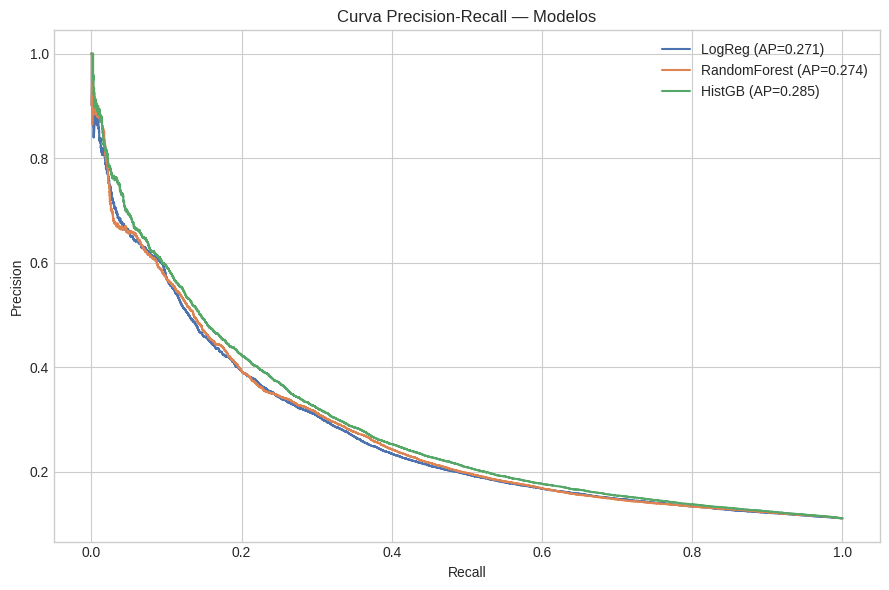

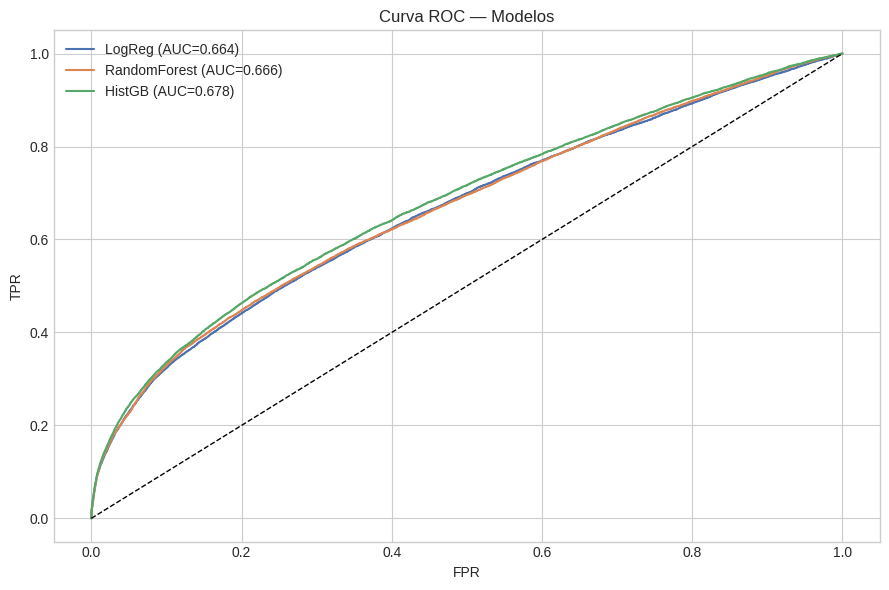

Salvos:
- ../results/figures/03_pr_curve_models.png
- ../results/figures/03_roc_curve_models.png


In [12]:
# PR Curve
plt.figure(figsize=(9, 6))
for model_name, result in search_results.items():
    y_prob = result["y_test_prob"]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f"{model_name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Modelos")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_pr_curve_models.png", dpi=150)
plt.show()

# ROC Curve
plt.figure(figsize=(9, 6))
for model_name, result in search_results.items():
    y_prob = result["y_test_prob"]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC — Modelos")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_roc_curve_models.png", dpi=150)
plt.show()

print("Salvos:")
print("-", FIGURES_DIR / "03_pr_curve_models.png")
print("-", FIGURES_DIR / "03_roc_curve_models.png")


### Comentário de leitura: PR e ROC
- A curva PR é central em base desbalanceada, pois evidencia o comportamento da classe positiva.
- ROC-AUC complementa a análise de discriminação global, mas não substitui a leitura de recall/precisão operacional.


## 12. Matrizes de confusão do melhor modelo


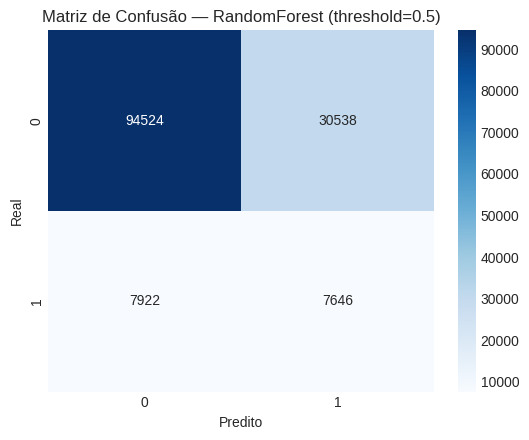

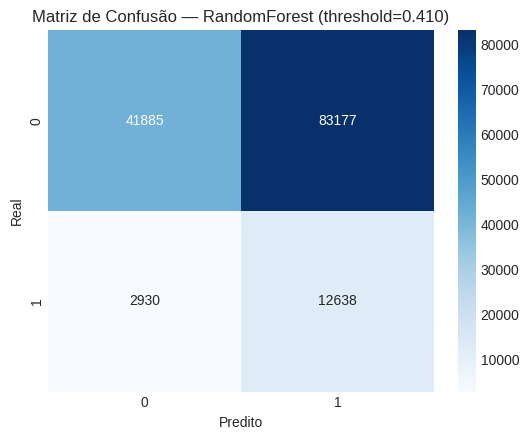

Salvos:
- ../results/figures/03_confusion_matrix_best_default.png
- ../results/figures/03_confusion_matrix_best_tuned.png


In [13]:
def plot_confusion(y_true, y_prob, threshold, title, output_file):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.savefig(output_file, dpi=150)
    plt.show()

plot_confusion(
    y_test,
    y_test_prob_best,
    threshold=0.5,
    title=f"Matriz de Confusão — {best_model_name} (threshold=0.5)",
    output_file=FIGURES_DIR / "03_confusion_matrix_best_default.png",
)

plot_confusion(
    y_test,
    y_test_prob_best,
    threshold=selected_threshold,
    title=f"Matriz de Confusão — {best_model_name} (threshold={selected_threshold:.3f})",
    output_file=FIGURES_DIR / "03_confusion_matrix_best_tuned.png",
)

print("Salvos:")
print("-", FIGURES_DIR / "03_confusion_matrix_best_default.png")
print("-", FIGURES_DIR / "03_confusion_matrix_best_tuned.png")


### Comentário de leitura: matrizes de confusão
- A matriz com threshold ajustado deve mostrar mais verdadeiros positivos e também mais falsos positivos.
- Esse comportamento confirma o objetivo da calibração: reduzir falso negativo em cenário de triagem.


## 13. Handoff para 04_interpretability

Mantém em memória:
- `best_model_name`
- `best_model`
- `rf_feature_ranking`


### Limitações e uso responsável
- O modelo é suporte à triagem e não substitui decisão clínica.
- Há risco de viés por cobertura, preenchimento e qualidade dos registros SINASC.
- Resultados devem ser interpretados junto ao contexto assistencial local.


In [14]:
rf_feature_ranking = None

if "RandomForest" in search_results:
    rf_model = search_results["RandomForest"]["best_estimator"]
    rf_feature_ranking = (
        pd.DataFrame({
            "feature": X_train.columns,
            "importance": rf_model.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(rf_feature_ranking.head(20))
else:
    print("RandomForest não encontrado em search_results.")

print("Objeto em memória para notebook 04:")
print("- best_model_name")
print("- best_model")
print("- rf_feature_ranking")


,feature,importance
0,GRAVIDEZ_UNICA,0.336388
1,KOTELCHUCK_MAIS_QUE_ADEQUADO,0.280660
2,KOTELCHUCK_INTERMEDIARIO,0.151100
3,MESPRENAT,0.022640
4,IDADEMAE,0.021544
5,PNTARDIO,0.019677
6,KOTELCHUCK_INADEQUADO,0.017686
7,QTDGESTANT,0.014809
8,FAIXAETAMAE_IDEAL,0.014666
9,QTDFILVIVO,0.013783


Objeto em memória para notebook 04:
- best_model_name
- best_model
- rf_feature_ranking
